In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option ('display.max_columns', None)

In [2]:
columns = [
    'srcip','sport','dstip','dsport','proto','state','dur',
    'sbytes','dbytes','sttl','dttl','sloss','dloss','service',
    'Sload','Dload','Spkts','Dpkts','swin','dwin','stcpb',
    'dtcpb','smeansz','dmeansz','trans_depth','res_bdy_len',
    'Sjit','Djit','Stime','Ltime','Sintpkt','Dintpkt',
    'tcprtt','synack','ackdat','is_sm_ips_ports',
    'ct_state_ttl','ct_flw_http_mthd','is_ftp_login',
    'ct_ftp_cmd','ct_srv_src','ct_srv_dst','ct_dst_ltm',
    'ct_src_ltm','ct_src_dport_ltm','ct_dst_sport_ltm',
    'ct_dst_src_ltm','attack_cat','label'
]

In [3]:
df1 = pd.read_csv("../data/raw/UNSW-NB15_1.csv", names=columns)
df2 = pd.read_csv("../data/raw/UNSW-NB15_2.csv", names=columns)
df3 = pd.read_csv("../data/raw/UNSW-NB15_3.csv", names=columns)
df4 = pd.read_csv("../data/raw/UNSW-NB15_4.csv", names=columns)

df = pd.concat([df1, df2, df3, df4], ignore_index=True)

print(df.shape)

/tmp/ipykernel_19928/3809669562.py:1: DtypeWarning: Columns (0: sport, 1: dsport, 2: attack_cat) have mixed types. Specify dtype option on import or set low_memory=False.
  df1 = pd.read_csv("../data/raw/UNSW-NB15_1.csv", names=columns)
/tmp/ipykernel_19928/3809669562.py:2: DtypeWarning: Columns (0: dsport, 1: ct_ftp_cmd, 2: attack_cat) have mixed types. Specify dtype option on import or set low_memory=False.
  df2 = pd.read_csv("../data/raw/UNSW-NB15_2.csv", names=columns)


(2540047, 49)


In [4]:
print(df.columns)

Index(['srcip', 'sport', 'dstip', 'dsport', 'proto', 'state', 'dur', 'sbytes',
       'dbytes', 'sttl', 'dttl', 'sloss', 'dloss', 'service', 'Sload', 'Dload',
       'Spkts', 'Dpkts', 'swin', 'dwin', 'stcpb', 'dtcpb', 'smeansz',
       'dmeansz', 'trans_depth', 'res_bdy_len', 'Sjit', 'Djit', 'Stime',
       'Ltime', 'Sintpkt', 'Dintpkt', 'tcprtt', 'synack', 'ackdat',
       'is_sm_ips_ports', 'ct_state_ttl', 'ct_flw_http_mthd', 'is_ftp_login',
       'ct_ftp_cmd', 'ct_srv_src', 'ct_srv_dst', 'ct_dst_ltm', 'ct_src_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'attack_cat',
       'label'],
      dtype='str')


In [5]:
print(df['label'].value_counts())

label
0    2218764
1     321283
Name: count, dtype: int64


In [6]:
print(df['attack_cat'].value_counts())

attack_cat
Generic             215481
Exploits             44525
 Fuzzers             19195
DoS                  16353
 Reconnaissance      12228
 Fuzzers              5051
Analysis              2677
Backdoor              1795
Reconnaissance        1759
 Shellcode            1288
Backdoors              534
Shellcode              223
Worms                  174
Name: count, dtype: int64


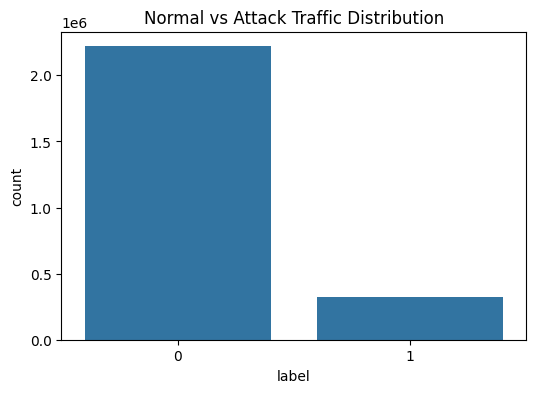

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Normal vs Attack Traffic Distribution")
plt.show()

In [8]:
print(df.isnull().sum().sort_values(ascending=False).head(10))

attack_cat          2218764
is_ftp_login        1429879
ct_flw_http_mthd    1348145
ct_state_ttl              0
Djit                      0
Stime                     0
Ltime                     0
Sintpkt                   0
Dintpkt                   0
tcprtt                    0
dtype: int64


In [9]:
df.sample(10000).to_csv("../data/sample/unsw_nb15_sample.csv", index=False)